In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [2]:
# 데이터 로드
df = pd.read_csv('../data/creditcard.csv')

In [3]:
# 기본 정보
print(df.shape)
print(df.info())
print(df.isnull().sum())

# 클래스 분포 확인 (핵심!)
print(df['Class'].value_counts())
print(f"사기 비율: {df['Class'].sum() / len(df) * 100:.3f}%")

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

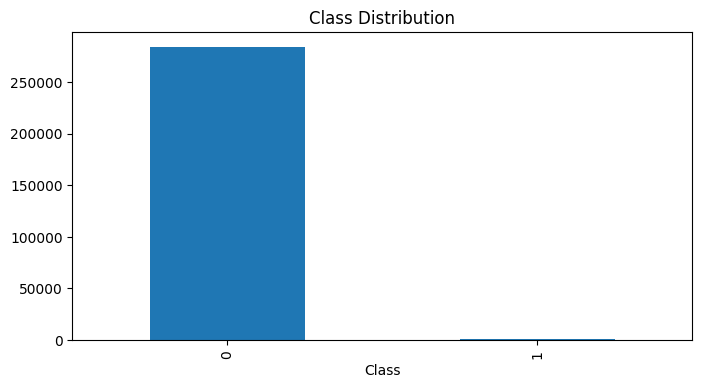

In [4]:
# 시각화
plt.figure(figsize=(8, 4))
df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

In [5]:
# Data전처리

# Amount와 Time 스케일링 (V1-V28은 이미 PCA 처리됨)
from sklearn.preprocessing import RobustScaler


# RobustScaler 적용
'''
    데이터의 중앙값을 뺀 다음, 사분위수 범위(IQR, Interquartile Range)로 나누어 데이터를 스케일링
    - Amount와 Time은 PCA 처리되지 않은 원본 변수라서 스케일링 필요
    - RobustScaler는 이상치(outlier)에 강건한 스케일링 방법 → 사기 거래 데이터에 적합
'''
scaler = RobustScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))


# 불필요한 컬럼 제거
df_processed = df.drop(['Amount', 'Time'], axis=1)
# 원본 Amount, Time은 스케일링된 버전으로 대체했으므로 제거


# 특성과 타겟 분리
X = df_processed.drop('Class', axis=1) # Class는 레이블 (0=정상, 1=사기)
y = df_processed['Class']


# 학습/테스트 분할 (stratify 중요!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=23, stratify=y
) # stratify=y 옵션이 핵심 → 불균형 데이터에서 학습/테스트에 사기 거래 비율을 동일하게 유지.


In [ ]:
# Logistic Regression (기본 모델)

# 필요한 라이브러리 불러오기
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
# -----------------------------
# 1. 데이터 불균형 처리 (SMOTE)
# -----------------------------
smote = SMOTE(random_state=23)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("원본 학습 데이터:", y_train.value_counts())
print("SMOTE 적용 후:", y_train_resampled.value_counts())

# -----------------------------
# 2. 기본 모델 학습 (Logistic Regression)
# -----------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=23)
log_reg.fit(X_train_resampled, y_train_resampled)

# -----------------------------
# 3. 예측 및 평가
# -----------------------------
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("\n[Classification Report]")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("recall:", recall_score(y_test, y_pred))


result_basic = '''
원본 학습 데이터: Class
0    227451
1       394
Name: count, dtype: int64
SMOTE 적용 후: Class
0    227451
1    227451
Name: count, dtype: int64

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.89      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.98      0.99     56962


ROC-AUC Score: 0.9600001579134748
recall: 0.8877551020408163
'''

c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


원본 학습 데이터: Class
0    227451
1       394
Name: count, dtype: int64
SMOTE 적용 후: Class
0    227451
1    227451
Name: count, dtype: int64

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.89      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.98      0.99     56962


ROC-AUC Score: 0.9600001579134748
recall: 0.8877551020408163


### 코드 설명
- LightGBM Dataset: 학습/테스트 데이터를 LightGBM 전용 포맷으로 변환
- 하이퍼파라미터:
    - is_unbalance=True: 클래스 불균형 자동 보정
    - num_leaves: 트리 복잡도 제어
    - feature_fraction, bagging_fraction: 과적합 방지
- early_stopping_rounds=50: 검증 AUC가 50번 연속 개선되지 않으면 학습 중단
- 평가 지표: ROC-AUC 중심으로 성능 확인

In [ ]:
# SMOTE 적용 후 LightGBM 학습 및 평가

'''
SMOTE로 균형 잡힌 학습 데이터를 기반으로 LightGBM을 학습하고, 
테스트셋에서는 원래의 불균형 데이터로 성능을 평가
'''
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import classification_report, roc_auc_score

# 모델 정의
lgb_clf = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    learning_rate=0.05,
    num_leaves=31,
    n_estimators=500,
    random_state=23
)

# 콜백 설정
callbacks = [
    early_stopping(stopping_rounds=50),  # 50번 동안 개선 없으면 중단
    log_evaluation(period=50)            # 50번째마다 로그 출력
]

# 학습
lgb_clf.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=callbacks
)

# 예측 및 평가
y_pred = lgb_clf.predict(X_test)
y_pred_proba = lgb_clf.predict_proba(X_test)[:, 1]

print("\n[Classification Report]")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("recall:", recall_score(y_test, y_pred))

result_basic_lgbm = '''
[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.09      0.87      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.93      0.58     56962
weighted avg       1.00      0.99      0.99     56962


ROC-AUC Score: 0.9695876592054943
recall: 0.8673469387755102
'''

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032946 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.964135	valid_0's binary_logloss: 0.0769212
Early stopping, best iteration is:
[12]	valid_0's auc: 0.969588	valid_0's binary_logloss: 0.34952

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.09      0.87      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.93      0.58     56962
weighted avg       1.00      0.99    